# Issues
- Sample rate too low for EDA and BVP (PPG) according to neurokit2

# To do list
- [ ] Use other filters
- [x] Filter later, raw signal for now
- [x] Split data into their respective blocks
- [ ] Extract features

In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import neurokit2 as nk
import math
import csv
import warnings

datafile='Extracted'
classes=['AEROBIC','ANAEROBIC','REST','STRESS']
desired_files = ['EDA', 'BVP', 'HR', 'TEMP','ACC']
from scipy.signal import cheby2,sosfilt

nyq = 0.5 * 64
low = 0.5 / nyq
high = 10 / nyq
sos = cheby2(4, 100, [low, high], btype='bandpass', fs=64, output='sos')

class VolData:
  def __init__(self,dataclass,link,eda,bvp,hr,temp,acc):
    self.dataclass=dataclass
    self.link=link #For debugging
    # self.eda=nk.signal_filter(eda, highcut=1.99, method="butterworth", order=5,sampling_rate=4)
    self.eda=eda
    self.bvp=nk.ppg_clean(bvp, sampling_rate=64,method='none')
    # self.bvp=nk.ppg_clean(sosfilt(sos, bvp), sampling_rate=64,method='none')
    self.hr=hr
    self.temp=temp
    self.acc=acc
  def getClass(self):
    return self.dataclass
  def getEDA(self):
    return self.eda
  def getBVP(self):
    return self.bvp
  def getHR(self):
    return self.hr
  def getTemp(self):
    return self.temp
  def getACC(self):
    return self.acc.values
  def getACCX(self):
    return self.acc[0].values
  def getACCY(self):
    return self.acc[1].values
  def getACCZ(self):
    return self.acc[2].values
  def getLink(self):
    return f'{datafile}/{self.dataclass}/{self.link}'
  
dataset =[] #order class: AERO > ANA > STRESS, S01 > f18

for clas in classes:
  volunteers=os.listdir(f'{datafile}/{clas}')
  if '.DS_Store' in volunteers: volunteers.remove('.DS_Store')
  volunteers.sort() #To make the volunteer files in order (Easier for debugging)

  for volunteer in volunteers:
    blocks=os.listdir(f'{datafile}/{clas}/{volunteer}')
    if '.DS_Store' in blocks: blocks.remove('.DS_Store')
    blocks.sort() #To make the volunteer files in order (Easier for debugging)
    for block in blocks:
      eda = pd.read_csv(f'{datafile}/{clas}/{volunteer}/{block}/EDA.csv',header=None)
      eda = eda[0].values

      bvp = pd.read_csv(f'{datafile}/{clas}/{volunteer}/{block}/BVP.csv',header=None)
      bvp = bvp.values

      hr = pd.read_csv(f'{datafile}/{clas}/{volunteer}/{block}/HR.csv',header=None)
      hr = hr[0].values

      temp = pd.read_csv(f'{datafile}/{clas}/{volunteer}/{block}/TEMP.csv',header=None)
      temp = temp[0].values

      acc = pd.read_csv(f'{datafile}/{clas}/{volunteer}/{block}/ACC.csv',header=None)

      dataset.append(VolData(clas,f'{volunteer}/{block}',eda,bvp,hr,temp,acc))

In [10]:
filename='feacher_bvp_cheby_100rs'
def moving_average(acc_data): #Obtained from wearable dataset ipynb
    # Initialization of variables
    avg = 0
    prevX, prevY, prevZ = 0, 0, 0
    results = []
    # Each second (32 samples) the acceleration data is summarized using the following method:
    for i in range(0, len(acc_data), 32):
        sum_ = 0
        buffX = acc_data[i:i+32, 0]
        buffY = acc_data[i:i+32, 1]
        buffZ = acc_data[i:i+32, 2]
        
        for j in range(len(buffX)):
            sum_ += max(
                abs(buffX[j] - prevX),
                abs(buffY[j] - prevY),
                abs(buffZ[j] - prevZ)
            )
            prevX, prevY, prevZ = buffX[j], buffY[j], buffZ[j]
        #The output is then filtered:
        avg = avg * 0.9 + (sum_ / 32) * 0.1 #
        results.append(avg)
    
    return results
def moving_average_axis(acc_data): #Obtained from wearable dataset ipynb
    # Initialization of variables
    avg = 0
    prev = 0
    results = []
    # Each second (32 samples) the acceleration data is summarized using the following method:
    for i in range(0, len(acc_data), 32):
        sum_ = 0
        buff = acc_data[i:i+32]
        
        for j in range(len(buff)):
            sum_ += abs(buff[j] - prev)
            prev = buff[j]
        #The output is then filtered:
        avg = avg * 0.9 + (sum_ / 32) * 0.1 #
        results.append(avg)
    
    return results

def change_ratio(signal):
    change_array=[]
    for i in range(len(signal)):
      if i+1 >= len(signal):
        break
      else:
        change=(signal[i+1]-signal[i])/signal[i]
        change_array.append(change)
    return change_array

def removeNan(value):
  cleanedList = [y for y in value if y == y]
  cleanedList = [y for y in cleanedList if math.isinf(y)==False]
  return cleanedList

def NantoZero(value):
  if np.isnan(value):
    return 0
  else:
    return value
warnings.filterwarnings("ignore", message="EDA signal is sampled at very low frequency. Skipping filtering.")
warnings.filterwarnings("ignore", message='invalid value encountered in scalar divide')
warnings.filterwarnings("ignore", message='divide by zero encountered in scalar divide')

# opening the csv file in 'w' mode
file = open(f'{filename}.csv', 'w', newline ='')

with file:
  # identifying header  
  header = ['Class', 'Link',
            'bvp_mean','bvp_std','bvp_max','bvp_min','bvp_max_ratio','bvp_min_ratio',
            'HR_mean', 'HR_std','HR_max','HR_min','HR_max_ratio','HR_min_ratio',
            'ibi_mean','ibi_max','ibi_min','HRV_pNN20','HRV_pNN50','HRV_RMSSD','HRV_MeanNN','HRV_MedianNN','HRV_MadNN','HRV_MCVNN','HRV_IQRNN','HRV_SDRMSSD','HRV_Prc20NN','HRV_Prc80NN','HRV_SDNN','HRV_SDANN1','HRV_SDNNI1','HRV_SDANN2','HRV_SDNNI2','HRV_SDANN5','HRV_SDNNI5','HRV_SDSD','HRV_CVNN','HRV_CVSD','HRV_MinNN','HRV_MaxNN','HRV_HTI','HRV_TINN',
            'HRV_VLF','HRV_LF','HRV_HF','HRV_VHF','HRV_TP','HRV_LFHF','HRV_LFn','HRV_HFn','HRV_LnHF',
            'EDA_Mean','EDA_std','EDA_Tonic_Mean','EDA_Phasic_Mean','EDA_Tonic_std','EDA_Phasic_std','EDA_Tonic_max_ratio','EDA_Tonic_min_ratio',
            'Peaks_density','SCR_Amplitude_Mean','SCR_Height_Mean','SCR_RiseTime_Mean','SCR_RecoveryTime_Mean','SCR_Amplitude_std','SCR_Height_std','SCR_RiseTime_std','SCR_RecoveryTime_std',
            'ACC_mean','ACC_std','ACC_max_ratio','ACC_min_ratio','ACC_max','ACC_min','x_mean','y_mean','z_mean','x_std','y_std','z_std','x_max_ratio','y_max_ratio','z_max_ratio','x_min_ratio','y_min_ratio','z_min_ratio','x_max','y_max','z_max','x_min','y_min','z_min',
            'TEMP_mean','TEMP_std','TEMP_max','TEMP_min','TEMP_max_ratio','TEMP_min_ratio']
  writer = csv.writer(file)
    
  # writing data row-wise into the csv file
  writer.writerow(header)
  for data in dataset:
    item_class=data.getClass()
    item_link=data.getLink()

    bvp=data.getBVP()
    bvp_mean=np.mean(bvp)
    bvp_std=np.std(bvp)
    bvp_max=max(bvp)
    bvp_min=min(bvp)
    bvp_max_ratio=max(removeNan(change_ratio(bvp)))
    bvp_min_ratio=min(removeNan(change_ratio(bvp)))
    
    hr=data.getHR()
    HR_mean=np.mean(hr)
    HR_std=np.std(hr)
    HR_max=max(hr)
    HR_min=min(hr)
    HR_max_ratio=max(change_ratio(hr))
    HR_min_ratio=min(change_ratio(hr))

    peaks, info=nk.ppg_peaks(data.getBVP(), sampling_rate=64)
    hrv=nk.hrv_time(info["PPG_Peaks"], sampling_rate=64)
    ibi_mean=hrv['HRV_MeanNN'][0]
    ibi_max=hrv['HRV_MaxNN'][0]
    ibi_min=hrv['HRV_MinNN'][0]
    HRV_pNN20=hrv['HRV_pNN20'][0]
    HRV_pNN50=hrv['HRV_pNN50'][0]
    HRV_RMSSD=hrv['HRV_RMSSD'][0]
    HRV_MeanNN=NantoZero(hrv['HRV_MeanNN'][0])
    HRV_MedianNN=NantoZero(hrv['HRV_MedianNN'][0])
    HRV_MadNN=NantoZero(hrv['HRV_MadNN'][0])
    HRV_MCVNN=NantoZero(hrv['HRV_MCVNN'][0])
    HRV_IQRNN=NantoZero(hrv['HRV_IQRNN'][0])
    HRV_SDRMSSD=NantoZero(hrv['HRV_SDRMSSD'][0])
    HRV_Prc20NN=NantoZero(hrv['HRV_Prc20NN'][0])
    HRV_Prc80NN=NantoZero(hrv['HRV_Prc80NN'][0])
    HRV_SDNN=hrv['HRV_SDNN'][0]
    HRV_SDANN1=NantoZero(hrv['HRV_SDANN1'][0])
    HRV_SDNNI1=NantoZero(hrv['HRV_SDNNI1'][0])
    HRV_SDANN2=NantoZero(hrv['HRV_SDANN2'][0])
    HRV_SDNNI2=NantoZero(hrv['HRV_SDNNI2'][0])
    HRV_SDANN5=NantoZero(hrv['HRV_SDANN5'][0])
    HRV_SDNNI5=NantoZero(hrv['HRV_SDNNI5'][0])
    HRV_SDSD=NantoZero(hrv['HRV_SDSD'][0])
    HRV_CVNN=NantoZero(hrv['HRV_CVNN'][0])
    HRV_CVSD=NantoZero(hrv['HRV_CVSD'][0])
    HRV_MinNN=NantoZero(hrv['HRV_MinNN'][0])
    HRV_MaxNN=NantoZero(hrv['HRV_MaxNN'][0])
    HRV_HTI=NantoZero(hrv['HRV_HTI'][0])
    HRV_TINN=NantoZero(hrv['HRV_HTI'][0])

    hrv_freq=nk.hrv_frequency(info["PPG_Peaks"], sampling_rate=64, vlf=(0, 0.04), lf=(0.04, 0.15), hf=(0.15, 0.4), vhf=(0.4, 2),silent=True)
    HRV_VLF=NantoZero(hrv_freq['HRV_VLF'][0])
    HRV_LF=NantoZero(hrv_freq['HRV_LF'][0])
    HRV_HF=NantoZero(hrv_freq['HRV_HF'][0])
    HRV_VHF=NantoZero(hrv_freq['HRV_VHF'][0])
    HRV_TP=NantoZero(hrv_freq['HRV_TP'][0])
    HRV_LFHF=NantoZero(hrv_freq['HRV_LFHF'][0])
    HRV_LFn=NantoZero(hrv_freq['HRV_LFn'][0])
    HRV_HFn=NantoZero(hrv_freq['HRV_HFn'][0])
    HRV_LnHF=NantoZero(hrv_freq['HRV_LnHF'][0])
    

    signal, info=nk.eda_process(data.getEDA(), sampling_rate=4)
    EDA_Mean=np.mean(signal['EDA_Raw'].values)
    EDA_std=np.std(signal['EDA_Raw'].values)
    EDA_Tonic_Mean=np.mean(signal['EDA_Tonic'].values)
    EDA_Phasic_Mean=np.mean(signal['EDA_Phasic'].values)
    EDA_Tonic_std=np.std(signal['EDA_Tonic'].values)
    EDA_Phasic_std=np.std(signal['EDA_Phasic'].values)
    EDA_Tonic_max_ratio=max(change_ratio(signal['EDA_Tonic'].values))
    EDA_Tonic_min_ratio=min(change_ratio(signal['EDA_Tonic'].values))
    Peaks_density=len([y for y in signal['SCR_Peaks'].values if y == 1])/len(signal['SCR_Peaks'].values)
    SCR_Amplitude_Mean=np.mean(removeNan(signal['SCR_Amplitude'].values))
    SCR_Height_Mean=np.mean(removeNan(signal['SCR_Height'].values))
    SCR_RiseTime_Mean=np.mean(removeNan(signal['SCR_RiseTime'].values))
    SCR_RecoveryTime_Mean=np.mean(removeNan(signal['SCR_RecoveryTime'].values))
    SCR_Amplitude_std=np.std(removeNan(signal['SCR_Amplitude'].values)) #Nan in initial list
    SCR_Height_std=np.std(removeNan(signal['SCR_Height'].values))
    SCR_RiseTime_std=np.std(removeNan(signal['SCR_RiseTime'].values)) #Nan in initial list
    SCR_RecoveryTime_std=np.std(removeNan(signal['SCR_RecoveryTime'].values)) #Nan in initial list

    acc_move=moving_average(data.getACC())
    ACC_mean=np.mean(acc_move)
    ACC_std=np.std(acc_move)
    ACC_max_ratio=max(change_ratio(acc_move))
    ACC_min_ratio=min(change_ratio(acc_move))
    ACC_max=max(acc_move)
    ACC_min=min(acc_move)
    x_mean=np.mean(moving_average_axis(data.getACCX()))
    y_mean=np.mean(moving_average_axis(data.getACCY()))
    z_mean=np.mean(moving_average_axis(data.getACCZ()))
    x_std=np.std(moving_average_axis(data.getACCX()))
    y_std=np.std(moving_average_axis(data.getACCY()))
    z_std=np.std(moving_average_axis(data.getACCZ()))
    x_max_ratio=max(removeNan(change_ratio(moving_average_axis(data.getACCX()))))
    y_max_ratio=max(removeNan(change_ratio(moving_average_axis(data.getACCY()))))
    z_max_ratio=max(removeNan(change_ratio(moving_average_axis(data.getACCZ()))))
    x_min_ratio=min(removeNan(change_ratio(moving_average_axis(data.getACCX()))))
    y_min_ratio=min(removeNan(change_ratio(moving_average_axis(data.getACCY()))))
    z_min_ratio=min(removeNan(change_ratio(moving_average_axis(data.getACCZ()))))
    x_max=max(moving_average_axis(data.getACCX()))
    y_max=max(moving_average_axis(data.getACCY()))
    z_max=max(moving_average_axis(data.getACCZ()))
    x_min=min(moving_average_axis(data.getACCX()))
    y_min=min(moving_average_axis(data.getACCY()))
    z_min=min(moving_average_axis(data.getACCZ()))

    temp=data.getTemp()
    TEMP_mean=np.mean(temp)
    TEMP_std=np.std(temp)
    TEMP_max=max(temp)
    TEMP_min=min(temp)
    TEMP_max_ratio=max(change_ratio(temp))
    TEMP_min_ratio=min(change_ratio(temp))

    writer.writerow([item_class,item_link,
                     bvp_mean,bvp_std,bvp_max,bvp_min,bvp_max_ratio,bvp_min_ratio,
                     HR_mean,HR_std,HR_max,HR_min,HR_max_ratio,HR_min_ratio,
                     ibi_mean,ibi_max,ibi_min,HRV_pNN20,HRV_pNN50,HRV_RMSSD,HRV_MeanNN,HRV_MedianNN,HRV_MadNN,HRV_MCVNN,HRV_IQRNN,HRV_SDRMSSD,HRV_Prc20NN,HRV_Prc80NN,HRV_SDNN,HRV_SDANN1,HRV_SDNNI1,HRV_SDANN2,HRV_SDNNI2,HRV_SDANN5,HRV_SDNNI5,HRV_SDSD,HRV_CVNN,HRV_CVSD,HRV_MinNN,HRV_MaxNN,HRV_HTI,HRV_TINN,
                     HRV_VLF,HRV_LF,HRV_HF,HRV_VHF,HRV_TP,HRV_LFHF,HRV_LFn,HRV_HFn,HRV_LnHF,
                     EDA_Mean,EDA_std,EDA_Tonic_Mean,EDA_Phasic_Mean,EDA_Tonic_std,EDA_Phasic_std,EDA_Tonic_max_ratio,EDA_Tonic_min_ratio,
                     Peaks_density,SCR_Amplitude_Mean,SCR_Height_Mean,SCR_RiseTime_Mean,SCR_RecoveryTime_Mean,SCR_Amplitude_std,SCR_Height_std,SCR_RiseTime_std,SCR_RecoveryTime_std,
                     ACC_mean,ACC_std,ACC_max_ratio,ACC_min_ratio,ACC_max,ACC_min,x_mean,y_mean,z_mean,x_std,y_std,z_std,x_max_ratio,y_max_ratio,z_max_ratio,x_min_ratio,y_min_ratio,z_min_ratio,x_max,y_max,z_max,x_min,y_min,z_min,
                     TEMP_mean,TEMP_std,TEMP_max,TEMP_min,TEMP_max_ratio,TEMP_min_ratio])
    if dataset.index(data)%20==0:
      print(dataset.index(data), end=" ") #Look at progress

0 20 40 60 80 100 120 140 160 180 200 220 240 260 

/Users/kiwimeow/anaconda3/lib/python3.11/site-packages/neurokit2/eda/eda_peaks.py:127: RuntimeWarning: All-NaN slice encountered
  info["SCR_Peaks"] > np.nanmin(info["SCR_Onsets"]), ~np.isnan(info["SCR_Onsets"])


280 300 320 340 360 380 400 420 440 

['HRV_MeanNN' 'HRV_SDNN' 'HRV_SDANN1' 'HRV_SDNNI1' 'HRV_SDANN2'
 'HRV_SDNNI2' 'HRV_SDANN5' 'HRV_SDNNI5' 'HRV_RMSSD' 'HRV_SDSD' 'HRV_CVNN'
 'HRV_CVSD' 'HRV_MedianNN' 'HRV_MadNN' 'HRV_MCVNN' 'HRV_IQRNN'
 'HRV_SDRMSSD' 'HRV_Prc20NN' 'HRV_Prc80NN' 'HRV_pNN50' 'HRV_pNN20'
 'HRV_MinNN' 'HRV_MaxNN' 'HRV_HTI' 'HRV_TINN']

['EDA_Raw' 'EDA_Clean' 'EDA_Tonic' 'EDA_Phasic' 'SCR_Onsets' 'SCR_Peaks'
 'SCR_Height' 'SCR_Amplitude' 'SCR_RiseTime' 'SCR_Recovery'
 'SCR_RecoveryTime']

 ['HRV_ULF' 'HRV_VLF' 'HRV_LF' 'HRV_HF' 'HRV_VHF' 'HRV_TP' 'HRV_LFHF'
 'HRV_LFn' 'HRV_HFn' 'HRV_LnHF']

In [4]:
peaks, info=nk.ppg_peaks(dataset[3].getBVP(), sampling_rate=64)
hrv=nk.hrv_time(info["PPG_Peaks"], sampling_rate=64)
print(list(hrv.columns))

['HRV_MeanNN', 'HRV_SDNN', 'HRV_SDANN1', 'HRV_SDNNI1', 'HRV_SDANN2', 'HRV_SDNNI2', 'HRV_SDANN5', 'HRV_SDNNI5', 'HRV_RMSSD', 'HRV_SDSD', 'HRV_CVNN', 'HRV_CVSD', 'HRV_MedianNN', 'HRV_MadNN', 'HRV_MCVNN', 'HRV_IQRNN', 'HRV_SDRMSSD', 'HRV_Prc20NN', 'HRV_Prc80NN', 'HRV_pNN50', 'HRV_pNN20', 'HRV_MinNN', 'HRV_MaxNN', 'HRV_HTI', 'HRV_TINN']


In [6]:
peaks, info=nk.ppg_peaks(dataset[3].getBVP(), sampling_rate=64)
# In the frequency domain, the power and peaks of each frequency band - Very Low Frequency (VLF: 0-0.04 Hz), Low Frequency (LF: 0.04-0.15 Hz), High Frequency (HF: 0.15-0.4 Hz), and Very High Frequency (VHF: 0.4-2 Hz) - were calculated. Total power, normalized LF and HF, and the LF/HF ratio were also computed.
hrv=nk.hrv_frequency(peaks, sampling_rate=64, vlf=(0, 0.04), lf=(0.04, 0.15), hf=(0.15, 0.4), vhf=(0.4, 2),silent=True)
print(list(hrv.columns))

['HRV_ULF', 'HRV_VLF', 'HRV_LF', 'HRV_HF', 'HRV_VHF', 'HRV_TP', 'HRV_LFHF', 'HRV_LFn', 'HRV_HFn', 'HRV_LnHF']


In [8]:
signal, info=nk.eda_process(dataset[0].getEDA(), sampling_rate=4)
print(list(signal.columns))

['EDA_Raw', 'EDA_Clean', 'EDA_Tonic', 'EDA_Phasic', 'SCR_Onsets', 'SCR_Peaks', 'SCR_Height', 'SCR_Amplitude', 'SCR_RiseTime', 'SCR_Recovery', 'SCR_RecoveryTime']


/Users/kiwimeow/anaconda3/lib/python3.11/site-packages/neurokit2/eda/eda_clean.py:105: NeuroKitWarning: EDA signal is sampled at very low frequency. Skipping filtering.
  warn(


In [6]:
for x in dataset:
  if max(x.getTemp()) > 50:
    print(max(x.getTemp()),min(x.getTemp()),x.getLink())

[208.39] [208.31] Extracted/AEROBIC/S07/rpm70
[220.53] [208.77] Extracted/AEROBIC/S07/rpm75
[220.93] [209.05] Extracted/AEROBIC/S07/rpm80
[221.29] [209.41] Extracted/AEROBIC/S07/rpm85
[209.41] [209.35] Extracted/ANAEROBIC/S02/sprint1
[221.35] [209.49] Extracted/ANAEROBIC/S02/sprint2
[228.99] [209.69] Extracted/ANAEROBIC/S02/sprint3
[209.07] [209.05] Extracted/ANAEROBIC/S05/sprint1
[209.45] [208.69] Extracted/ANAEROBIC/S05/sprint2


In [30]:
print(change_ratio(moving_average_axis(dataset[308].getACCY())))
print(dataset[308].getLink())

[inf, 1.9000000000000001, 0.24482758620689674, -0.10000000000000003, 0.8233610341643581, 0.9128120727199066, 0.07649618018142033, 0.2279086046578926, 0.3005696394023371, 0.15666294423778704, 0.0775196105426697, -0.05881290493328788, -0.012478410971428237, 0.07725503928408689, -0.017728377765637703, -0.058121755544958104, -0.10000000000000002, -0.050597242263784564, -0.047964383573086765, -0.0180141758421682, 0.1504694736142782, 0.48056177206199996, 0.2594457417666467, -0.048109101438044775, 0.10442560161180747, 0.07275697692318017, 0.09554879029794122, 0.046994987052623755, 0.00028359316110600295, -0.0799489677034113, -0.05641321710918943, -0.053807340584745934, 0.09527802908046688, -0.09999999999999994, -0.09999999999999995, -0.05872897449583608]
Extracted/STRESS/S01/Subtract


/var/folders/_j/qc2yfyd96wv7qfg68l8trrvc0000gn/T/ipykernel_1826/1903527024.py:50: RuntimeWarning: divide by zero encountered in scalar divide
  change=(signal[i+1]-signal[i])/signal[i]


<Axes: >

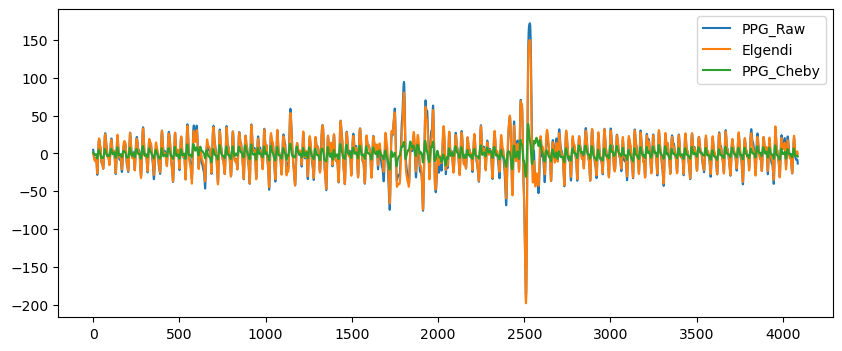

In [25]:
# Simulate and clean signal

ppg = dataset[0].getBVP()

ppg_elgendi = nk.ppg_clean(ppg, method='elgendi', sampling_rate=64)

nyq = 0.5 * 64
low = 0.5 / nyq
high = 10 / nyq
sos = cheby2(4, 10, [low, high], btype='bandpass', fs=64, output='sos', analog=False)
bvp_filtered = sosfilt(sos, ppg)

# Plot and compare methods
signals = pd.DataFrame({'PPG_Raw' : ppg,
                        "Elgendi":ppg_elgendi,
                        'PPG_Cheby':bvp_filtered})

signals.plot(figsize=(10, 4))

[ 1.47073098  1.10228699  0.53591854 ... -2.62782782 -3.13329644
 -4.07115388]


<Axes: >

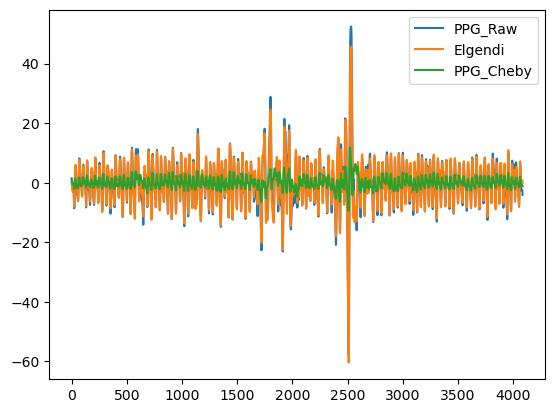

In [36]:
# Simulate and clean signal

ppg = dataset[0].getBVP()

ppg_elgendi = nk.ppg_clean(ppg, method='elgendi', sampling_rate=64)

nyq = 0.5 * 64
low = 0.5 / nyq
high = 10 / nyq
sos = cheby2(4, 10, [low, high], btype='bandpass', fs=64, output='sos')
bvp_filtered = sosfilt(sos, ppg)

print(ppg)
# Plot and compare methods
signals = pd.DataFrame({'PPG_Raw' : ppg,
                        "Elgendi":ppg_elgendi,
                        'PPG_Cheby':bvp_filtered})

signals.plot()